# Convolutional Autoencoder with Nearest-neighbor Interpolation

In [63]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

## DATASET

In [64]:
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize and preprocess
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


## Settings

In [65]:
# Hyperparameters
learning_rate = 0.001
training_epochs = 5
batch_size = 128

# Architecture
input_size = 784
image_width = 28

# Other
print_interval = 200
random_seed = 123

## GRAPH DEFINITION

In [75]:
pip install tensorflow==2.13

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.2/524.2 MB 3.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 100.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 108.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.8/440.8 kB 27.8 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.14.0
    Uninstalling typing_extensions-4.14.0:
      Successfully uninstalled typing_extensions-4.14.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
  Attempting uninstall: gast
    Found existing installation: gast 0.6.0
    Uni

In [93]:
g = tf.Graph()
with g.as_default():
    
    tf.compat.v1.set_random_seed(random_seed)

    # Input data
    tf_x = tf.compat.v1.placeholder(tf.float32, [None, input_size], name='inputs')
    input_layer = tf.reshape(tf_x, shape=[-1, image_width, image_width, 1])

    # Encoder
    
    # 28x28x1 => 28x28x8
    conv1 = tf.keras.layers.Conv2D(
        filters=8,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding='same',
        activation='relu'
    )(input_layer)
    
    # 28x28x8 => 14x14x8
    maxpool1 = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=(2, 2),
        padding='same'
    )(conv1)
    
    # 14x14x8 => 14x14x4
    conv2 = tf.keras.layers.Conv2D(
        filters=4,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding="same",
        activation="relu"
    )(maxpool1)
    
    # 14x14x4 => 7x7x4
    encode = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=(2, 2),
        padding='same',
        name='encoding'
    )(conv2)

    # Decoder
    
    # 7x7x4 => 14x14x4
    deconv1 = tf.image.resize(
        encode,
        size=(14, 14),
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )
    # 14x14x4 => 14x14x8
    conv3 = tf.keras.layers.Conv2D(
        filters=8,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding='same',
        activation='relu'
    )(deconv1)
    
    # 14x14x8 => 28x28x8
    deconv2 = tf.image.resize(conv3, size=(28, 28), method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    # 28x28x8 => 28x28x8
    conv4 = tf.keras.layers.Conv2D(filters=8, kernel_size=(3, 3), 
                             strides=(1, 1), padding='same', 
                             activation='relu')(deconv2)
    # 28x28x8 => 28x28x1
    logits = tf.keras.layers.Conv2D(
        filters=1,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding='same',
        activation=None
    )(conv4)
    
    decode = tf.nn.sigmoid(logits, name='decoding')

    # Loss & Optimizer
    
    loss = tf.nn.sigmoid_cross_entropy_with_logits(labels=input_layer,
                                                   logits=logits)
    cost = tf.reduce_mean(loss, name='cost')
    optimizer = tf.compat.v1.train.AdamOptimizer(learning_rate)
    train = optimizer.minimize(cost, name='train')    

    # Saver to save session for reuse
    saver = tf.compat.v1.train.Saver()

## TRAINING & EVALUATION

In [98]:
import numpy as np
import tensorflow as tf

tf.compat.v1.disable_eager_execution()   # important!

with tf.compat.v1.Session(graph=g) as sess:
    sess.run(tf.compat.v1.global_variables_initializer())

    np.random.seed(random_seed)  # random seed for batching
    num_examples = x_train.shape[0]

    for epoch in range(training_epochs):
        avg_cost = 0.0
        total_batch = num_examples // batch_size

        # shuffle each epoch
        indices = np.arange(num_examples)
        np.random.shuffle(indices)
        x_train_shuffled = x_train[indices]
        y_train_shuffled = y_train[indices]

        for i in range(total_batch):
            start = i * batch_size
            end = start + batch_size
            batch_x = x_train_shuffled[start:end].reshape(-1, 784)  # flatten
            batch_y = y_train_shuffled[start:end]

            _, c = sess.run(
                ['train', 'cost:0'],
                feed_dict={'inputs:0': batch_x}
            )
            avg_cost += c

            if not i % print_interval:
                print("Minibatch: %03d | Cost: %.3f" % (i + 1, c))

        print("Epoch: %03d | AvgCost: %.3f" % (epoch + 1, avg_cost / (i + 1)))

    saver = tf.compat.v1.train.Saver()
    saver.save(sess, './autoencoder.ckpt')

I0000 00:00:1759143815.116908      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15405 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1759143815.395291     109 cuda_dnn.cc:529] Loaded cuDNN version 90300


Minibatch: 001 | Cost: 0.666
Minibatch: 201 | Cost: 0.117
Minibatch: 401 | Cost: 0.100
Epoch: 001 | AvgCost: 0.163
Minibatch: 001 | Cost: 0.100
Minibatch: 201 | Cost: 0.093
Minibatch: 401 | Cost: 0.088
Epoch: 002 | AvgCost: 0.093
Minibatch: 001 | Cost: 0.088
Minibatch: 201 | Cost: 0.085
Minibatch: 401 | Cost: 0.086
Epoch: 003 | AvgCost: 0.088
Minibatch: 001 | Cost: 0.084
Minibatch: 201 | Cost: 0.085
Minibatch: 401 | Cost: 0.086
Epoch: 004 | AvgCost: 0.085
Minibatch: 001 | Cost: 0.081
Minibatch: 201 | Cost: 0.088
Minibatch: 401 | Cost: 0.085
Epoch: 005 | AvgCost: 0.084


## VISUALIZATION

I0000 00:00:1759143920.896601      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15405 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


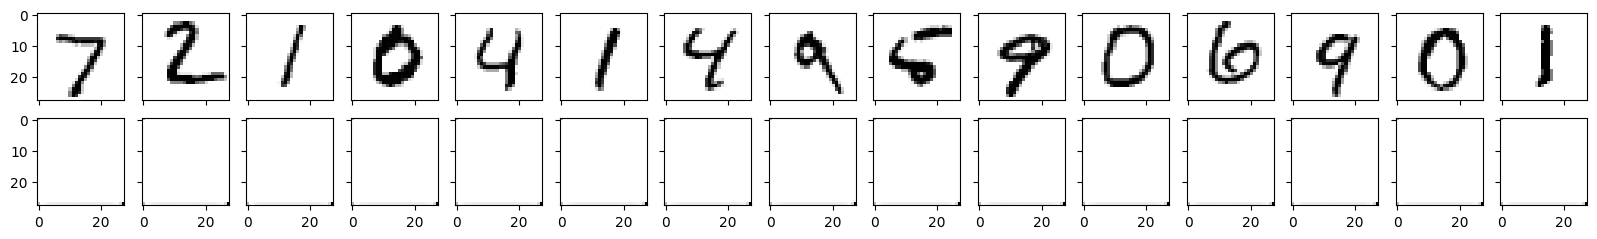

In [103]:
import matplotlib.pyplot as plt

n_images = 15

fig, axes = plt.subplots(nrows=2, ncols=n_images, sharex=True, 
                         sharey=True, figsize=(20, 2.5))
test_images = x_test[:n_images].reshape(-1, 784) / 255.0

with tf.compat.v1.Session(graph=g) as sess:
    saver.restore(sess, save_path='./autoencoder.ckpt')
    decoded = sess.run('decoding:0', feed_dict={'inputs:0': test_images})

for i in range(n_images):
    for ax, img in zip(axes, [test_images, decoded]):
        ax[i].imshow(img[i].reshape((image_width, image_width)), cmap='binary')